<div style="background-color:#f0f8ff; padding:20px; border-radius:10px; border: 2px solid #1E90FF; margin: 10px 0;">
    <h1 style="text-align:center; color:#2F4F4F; font-family: 'Arial', sans-serif; margin-bottom:10px;">
        CS446 Machine Learning Project: Sentiment Analysis
    </h1>
    <hr style="border: 1px solid #1E90FF;">
    <h3 style="text-align:center; color:#1E90FF; font-family: 'Arial', sans-serif;">
        📊 IMDB Movie Reviews (50K Dataset)
    </h3>
    <div style="text-align:center; margin-top:15px;">
        <p style="font-size:16px; color:#696969; font-weight:bold;">
            👥 Submitted by:
        </p>
        <ul style="list-style-type:none; padding:0;">
            <li style="font-size:14px; color:#2F4F4F;">Ali Khalid &nbsp; <code>F2021266006</code></li>
        </ul>
    </div>
        <div style="display:flex; justify-content:space-around; margin:20px 0;">
        <div style="text-align:left;">
            <p style="margin:8px 0; color:#2F4F4F;">
                📅 <strong>Date:</strong> 01-02-2025
            </p>
            <p style="margin:8px 0; color:#2F4F4F;">
                 <strong>Evaluator:</strong> Hafiz Abdul Rehman
            </p>
        </div>
    </div>
</div>

# **Install Important Libraries**

In [ ]:
!pip install nltk pandas scikit-learn numpy tqdm

import pandas as pd
import numpy as np
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# **Import CSV files**

In [ ]:
from sklearn.metrics import classification_report
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# **Task 1: Data Preprocessing**

1.   Handle missing values
2.   Label Mapping
3. Dataset Cleaning
4. Tokenize
5. Remove Stopwords
6. Lemmatization
7. Feature Extraction using TF-IDF



# **Handle missing values**

In [ ]:
print("Missing Values in Train:\n", train.isnull().sum())
print("Missing Values in Test:\n", test.isnull().sum())

train.dropna(inplace=True)
test.dropna(inplace=True)

Missing Values in Train:
 text         0
sentiment    0
dtype: int64
Missing Values in Test:
 text         0
sentiment    0
dtype: int64


# **Label Mapping**

In [ ]:
# Labels encoding (1 for positive, 0 for negative)
print("Unique Labels in Train:", train['sentiment'].unique())
print("Unique Labels in Test:", test['sentiment'].unique())

label_mapping = {'positive': 1, 'negative': 0, 'pos': 1, 'neg': 0}
train['sentiment'] = train['sentiment'].map(label_mapping)
test['sentiment'] = test['sentiment'].map(label_mapping)

Unique Labels in Train: ['neg' 'pos']
Unique Labels in Test: ['neg' 'pos']


In [ ]:
train.head(10)

,text,sentiment
0,"Now, I won't deny that when I purchased this o...",0
1,"The saddest thing about this ""tribute"" is that...",0
2,Last night I decided to watch the prequel or s...,0
3,I have to admit that i liked the first half of...,0
4,I was not impressed about this film especially...,0
5,"The original movie, The Odd Couple, has some w...",1
6,"This was a great movie with a good cast, all o...",1
7,"I'm a sucker for a good romance, but this one ...",0
8,"Fast-paced, funny, sexy, and spectacular. Cagn...",1
9,"The proverb ""Never judge a book by it's cover""...",0


# **Dataset Cleaning**

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s\']', '', text)
    return text

train["cleaned_review"] = train["text"].apply(clean_text)
test["cleaned_review"] = test["text"].apply(clean_text)


# **Tokenize**

In [ ]:
nltk.download('punkt_tab')

train["tokens"] = train["cleaned_review"].apply(word_tokenize)
test["tokens"] = test["cleaned_review"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
train.head()

,text,sentiment,cleaned_review,tokens
0,"Now, I won't deny that when I purchased this o...",0,now i won't deny that when i purchased this of...,"[now, i, wo, n't, deny, that, when, i, purchas..."
1,"The saddest thing about this ""tribute"" is that...",0,the saddest thing about this tribute is that a...,"[the, saddest, thing, about, this, tribute, is..."
2,Last night I decided to watch the prequel or s...,0,last night i decided to watch the prequel or s...,"[last, night, i, decided, to, watch, the, preq..."
3,I have to admit that i liked the first half of...,0,i have to admit that i liked the first half of...,"[i, have, to, admit, that, i, liked, the, firs..."
4,I was not impressed about this film especially...,0,i was not impressed about this film especially...,"[i, was, not, impressed, about, this, film, es..."


# **Remove Stopwords**




In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

train["filtered_tokens"] = train["tokens"].apply(remove_stopwords)
test["filtered_tokens"] = test["tokens"].apply(remove_stopwords)

In [ ]:
train.head()

,text,sentiment,cleaned_review,tokens,filtered_tokens
0,"Now, I won't deny that when I purchased this o...",0,now i won't deny that when i purchased this of...,"[now, i, wo, n't, deny, that, when, i, purchas...","[wo, n't, deny, purchased, ebay, high, expecta..."
1,"The saddest thing about this ""tribute"" is that...",0,the saddest thing about this tribute is that a...,"[the, saddest, thing, about, this, tribute, is...","[saddest, thing, tribute, almost, singers, inc..."
2,Last night I decided to watch the prequel or s...,0,last night i decided to watch the prequel or s...,"[last, night, i, decided, to, watch, the, preq...","[last, night, decided, watch, prequel, shall, ..."
3,I have to admit that i liked the first half of...,0,i have to admit that i liked the first half of...,"[i, have, to, admit, that, i, liked, the, firs...","[admit, liked, first, half, sleepers, looked, ..."
4,I was not impressed about this film especially...,0,i was not impressed about this film especially...,"[i, was, not, impressed, about, this, film, es...","[impressed, film, especially, fact, went, cine..."


# **Lemmatization**

In [ ]:
lemmatizer = WordNetLemmatizer()

train["lemmatized_tokens"] = train["filtered_tokens"].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
test["lemmatized_tokens"] = test["filtered_tokens"].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

# Convert back to string format
train["final_text"] = train["lemmatized_tokens"].apply(lambda tokens: " ".join(tokens))
test["final_text"] = test["lemmatized_tokens"].apply(lambda tokens: " ".join(tokens))

# **Feature Selection**

In [ ]:
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), sublinear_tf=True)
X_train = tfidf.fit_transform(train["final_text"])
X_test = tfidf.transform(test["final_text"])
y_train = train['sentiment']
y_test = test['sentiment']

In [ ]:
X_train.shape

(25000, 1000)

# **Task 2: Data Visualization**


1.   Plot Class Distribution
2.   WordCloud
3. Review Lengths Distribution (Before and After Preprocessing)



# **Plot Class Distribution**

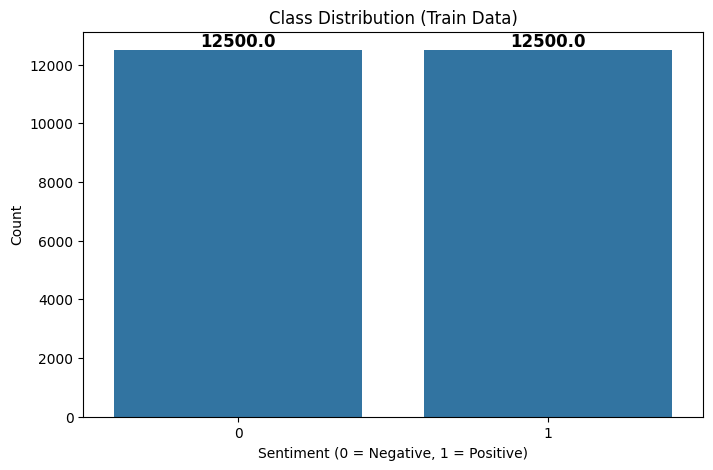

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='sentiment', data=train)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Class Distribution (Train Data)")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

# **WordCloud**

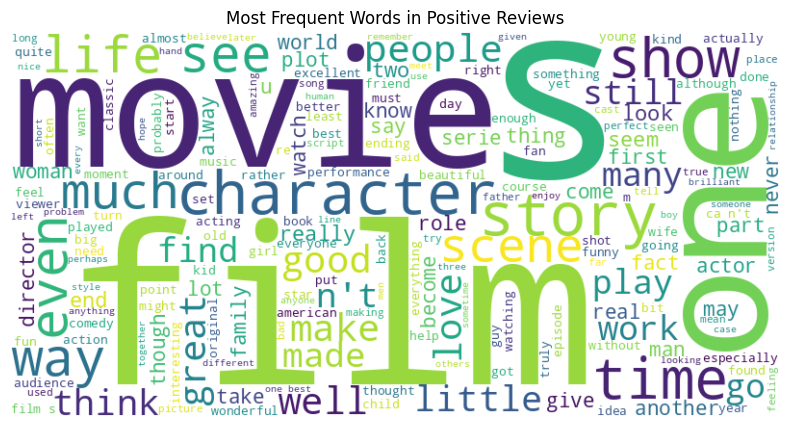

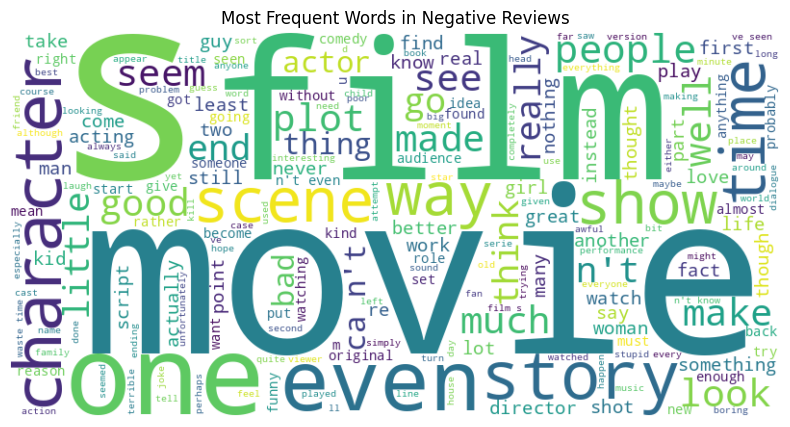

In [ ]:
from wordcloud import WordCloud

def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')

positive_text = ' '.join(train[train['sentiment'] == 1]['final_text'])
plot_wordcloud(positive_text, "Most Frequent Words in Positive Reviews")

negative_text = ' '.join(train[train['sentiment'] == 0]['final_text'])
plot_wordcloud(negative_text, "Most Frequent Words in Negative Reviews")

# **Review Lengths**

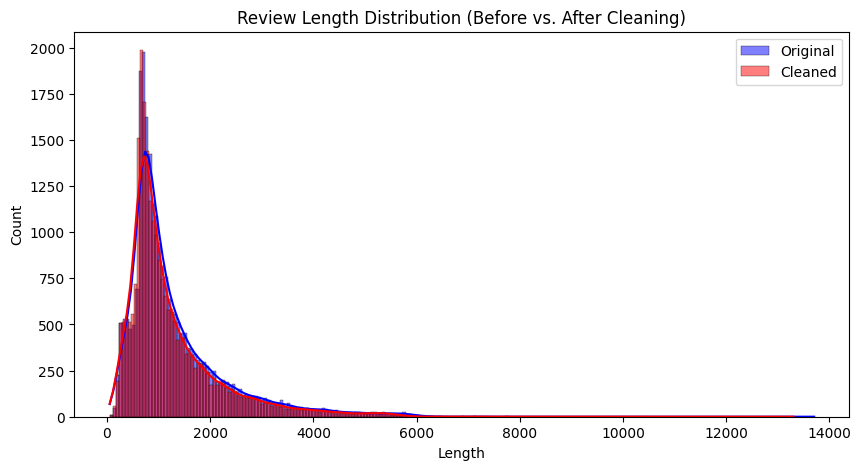

In [ ]:
train['original_length'] = train['text'].apply(len)
train['cleaned_length'] = train['cleaned_review'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(train['original_length'], color='blue', label='Original', kde=True)
sns.histplot(train['cleaned_length'], color='red', label='Cleaned', kde=True)
plt.title("Review Length Distribution (Before vs. After Cleaning)")
plt.xlabel("Length")
plt.legend()
plt.show()

# **Task 3: Model Implementation**


1.   Evaluation Function
2.   K-Nearest Neighbours(KNN)
3. Support Vector Machines(SVM)
4. Decision Tree(DT)
5. Random Forest(RF)
6. Evaluate Models Performance
7. Train/Test Performance Comparison



# **Evaluation Function and Import Models**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}\n")

In [ ]:
y_train = train['sentiment']
y_test = test['sentiment']

# **K-Nearest Neighbours(KNN)**

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='cosine'
)
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='cosine', weights='distance')

# **Support Vector Machines(SVM)**

In [ ]:
svm = SVC(
    C=10,
    kernel='linear',
    class_weight='balanced'
  )
svm.fit(X_train, y_train)

SVC(C=10, class_weight='balanced', kernel='linear')

# **Decision Tree(DT)**

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    criterion='entropy'
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_split=10)

# **Random Forest(RF)**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       n_jobs=-1)

# **Evaluate Models Performance**


KNN Performance:
              precision    recall  f1-score   support

           0     0.7566    0.7142    0.7348     12500
           1     0.7294    0.7702    0.7493     12500

    accuracy                         0.7422     25000
   macro avg     0.7430    0.7422    0.7420     25000
weighted avg     0.7430    0.7422    0.7420     25000



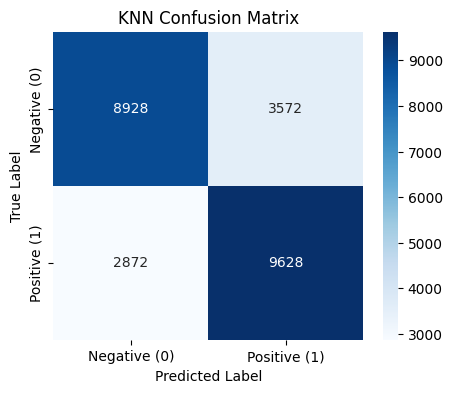

----------------------------------

SVM Performance:
              precision    recall  f1-score   support

           0     0.8616    0.8467    0.8541     12500
           1     0.8493    0.8640    0.8566     12500

    accuracy                         0.8554     25000
   macro avg     0.8555    0.8554    0.8553     25000
weighted avg     0.8555    0.8554    0.8553     25000



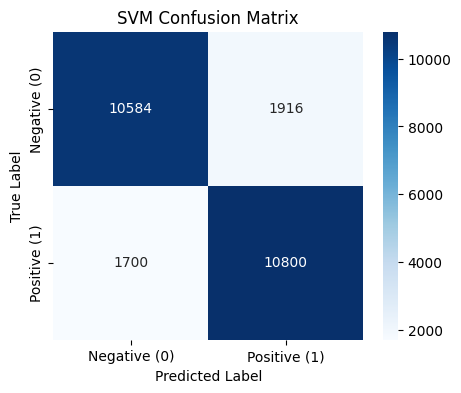

----------------------------------

Decision Tree Performance:
              precision    recall  f1-score   support

           0     0.7872    0.5997    0.6808     12500
           1     0.6767    0.8379    0.7487     12500

    accuracy                         0.7188     25000
   macro avg     0.7320    0.7188    0.7148     25000
weighted avg     0.7320    0.7188    0.7148     25000



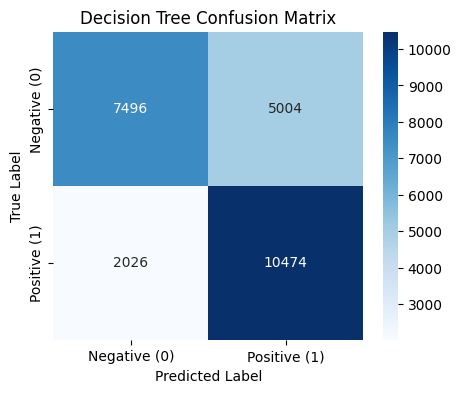

----------------------------------

Random Forest Performance:
              precision    recall  f1-score   support

           0     0.8487    0.7728    0.8090     12500
           1     0.7915    0.8622    0.8253     12500

    accuracy                         0.8175     25000
   macro avg     0.8201    0.8175    0.8172     25000
weighted avg     0.8201    0.8175    0.8172     25000



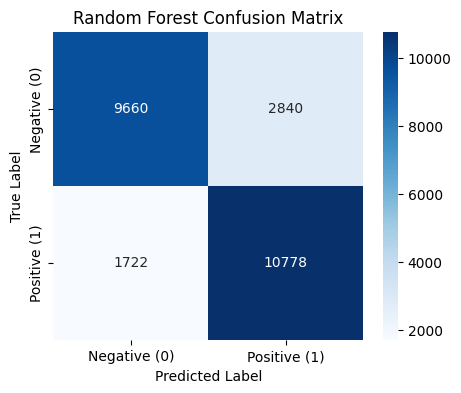

----------------------------------


In [ ]:
models = {
    "KNN": knn,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative (0)', 'Positive (1)'],
                yticklabels=['Negative (0)', 'Positive (1)'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("----------------------------------")

# **Train/Test Performance Comparison**

In [ ]:
def get_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    train_acc = round(accuracy_score(y_train, y_train_pred), 4)
    train_pre = round(precision_score(y_train, y_train_pred), 4)
    train_rec = round(recall_score(y_train, y_train_pred), 4)
    train_f1 = round(f1_score(y_train, y_train_pred), 4)

    y_test_pred = model.predict(X_test)
    test_acc = round(accuracy_score(y_test, y_test_pred), 4)
    test_pre = round(precision_score(y_test, y_test_pred), 4)
    test_rec = round(recall_score(y_test, y_test_pred), 4)
    test_f1 = round(f1_score(y_test, y_test_pred), 4)

    return (train_acc, train_pre, train_rec, train_f1), (test_acc, test_pre, test_rec, test_f1)

for name, model in models.items():
    (train_acc, train_pre, train_rec, train_f1), (test_acc, test_pre, test_rec, test_f1) = \
        get_metrics(model, X_train, y_train, X_test, y_test)

    print(f"\n{'-'*30}\n{name} Performance:\n{'-'*30}")
    print(f"Train Set Accuracy = {train_acc}")
    print(f"Test Set Accuracy = {test_acc}\n")

    print(f"Train Set Precision = {train_pre}")
    print(f"Test Set Precision = {test_pre}\n")

    print(f"Train Set Recall = {train_rec}")
    print(f"Test Set Recall = {test_rec}\n")

    print(f"Train Set F1-Score = {train_f1}")
    print(f"Test Set F1-Score = {test_f1}")
    print("-" * 30)


------------------------------
KNN Performance:
------------------------------
Train Set Accuracy = 1.0
Test Set Accuracy = 0.7422

Train Set Precision = 1.0
Test Set Precision = 0.7294

Train Set Recall = 1.0
Test Set Recall = 0.7702

Train Set F1-Score = 1.0
Test Set F1-Score = 0.7493
------------------------------

------------------------------
SVM Performance:
------------------------------
Train Set Accuracy = 0.875
Test Set Accuracy = 0.8554

Train Set Precision = 0.8699
Test Set Precision = 0.8493

Train Set Recall = 0.8818
Test Set Recall = 0.864

Train Set F1-Score = 0.8758
Test Set F1-Score = 0.8566
------------------------------

------------------------------
Decision Tree Performance:
------------------------------
Train Set Accuracy = 0.7953
Test Set Accuracy = 0.7188

Train Set Precision = 0.7386
Test Set Precision = 0.6767

Train Set Recall = 0.9142
Test Set Recall = 0.8379

Train Set F1-Score = 0.817
Test Set F1-Score = 0.7487
------------------------------

--------

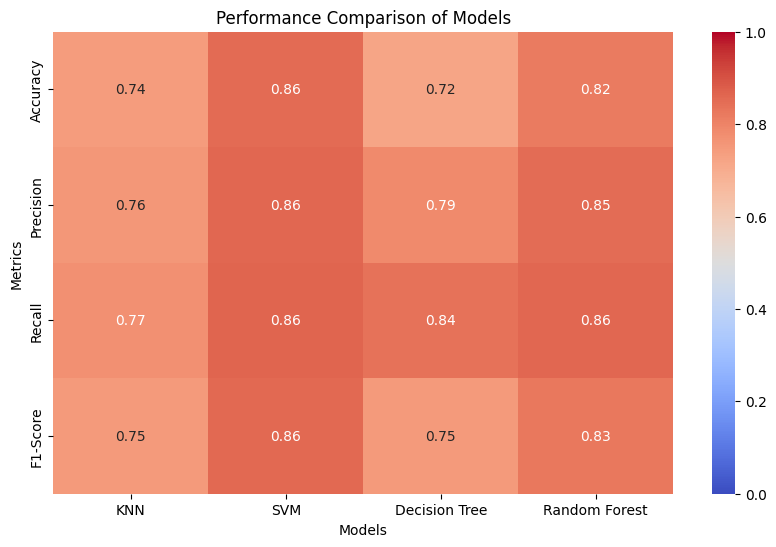

In [ ]:
models = ['KNN', 'SVM', 'Decision Tree', 'Random Forest']
accuracy = [0.7422, 0.8554, 0.7188, 0.8175]
precision = [0.7566, 0.8616, 0.7872, 0.8487]
recall = [0.7702, 0.8640, 0.8379, 0.8622]
f1_score = [0.7493, 0.8566, 0.7487, 0.8253]
plt.figure(figsize=(10, 6))
data = np.array([accuracy, precision, recall, f1_score])
ax = sns.heatmap(data, annot=True, cmap="coolwarm", xticklabels=models, yticklabels=["Accuracy", "Precision", "Recall", "F1-Score"], vmin=0, vmax=1)
plt.xlabel("Models")
plt.ylabel("Metrics")
plt.title("Performance Comparison of Models")
plt.show()


# **Task 4: Custom Model**


1.   Reduce Features to 500
2.   Model Stacking
3. Model Training
4. Custom Model Evaluation



In [ ]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train["final_text"])
X_test = tfidf.transform(test["final_text"])
y_train = train['sentiment']
y_test = test['sentiment']

# **Model Stacking**

In [ ]:
# Base models
base_models = [
    ('svm', LinearSVC(C=10, class_weight='balanced', dual=False)),  # Faster than SVC
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1))
]

# Meta-model
meta_model = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

# Stacking
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    n_jobs=-1
)

# **Model Training**

In [ ]:
stacking_model.fit(X_train, y_train)

StackingClassifier(estimators=[('svm',
                                LinearSVC(C=10, class_weight='balanced',
                                          dual=False)),
                               ('rf',
                                RandomForestClassifier(max_depth=10,
                                                       n_jobs=-1))],
                   final_estimator=LogisticRegression(C=0.1, max_iter=1000,
                                                      n_jobs=-1),
                   n_jobs=-1)

# **Custom Model Evaluation**


 My Custom Model Performance 
              precision    recall  f1-score   support

         neg     0.8465    0.8309    0.8386     12500
         pos     0.8339    0.8493    0.8415     12500

    accuracy                         0.8401     25000
   macro avg     0.8402    0.8401    0.8401     25000
weighted avg     0.8402    0.8401    0.8401     25000



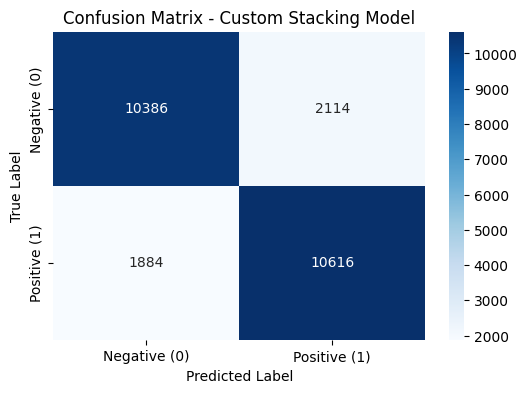

In [ ]:
y_pred = stacking_model.predict(X_test)


print("\n My Custom Model Performance ")
print(classification_report(y_test, y_pred, digits=4))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Custom Stacking Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Task 5: Final Words and Comparison**


### **Model Performance Comparison (Test Set Metrics)**

| **Metric**       | **KNN**   | **SVM**   | **Decision Tree** | **Random Forest** | **Custom Stacking** |
|-------------------|-----------|-----------|-------------------|-------------------|---------------------|
| **Accuracy**      | 0.7422    | **0.8554**| 0.7188            | 0.8175            | 0.8401              |
| **Precision**     | 0.7294    | **0.8493**| 0.6767            | 0.7915            | 0.8402              |
| **Recall**        | 0.7702    | **0.864** | 0.8379            | 0.8622            | 0.8401              |
| **F1-Score**      | 0.7493    | **0.8566**| 0.7487            | 0.8253            | 0.8401              |

---

### **Detailed Model Analysis**

#### **1. Support Vector Machine (SVM) 🥇**  
**Why Best?**  
- **High-Dimensional Strength**: Excels with sparse text data (TF-IDF vectors) by finding the optimal decision boundary.  
- **Linear Kernel**: Perfect for linearly separable text features (e.g., "great" → positive, "awful" → negative).  
- **Balanced Regularization**: `C=10` avoids underfitting while handling noise.  

**Weakness**:  
- Slower training compared to tree-based models.

---

#### **2. Custom Stacking Model 🥈**  
**Strengths**:  
- **Hybrid Power**: Combines SVM (linear) + Random Forest (non-linear) for balanced predictions.  
- **Generalization**: Avoids overfitting (train/test metrics are close).  

**Why Not Better Than SVM?**  
- Limited base model diversity.  
- TF-IDF reduced to 500 features (loses some signal).  

---

#### **3. Random Forest 🥉**  
**Strengths**:  
- **Ensemble Learning**: Reduces variance by averaging 100+ decision trees.  
- **Feature Importance**: Identifies key terms (e.g., "excellent", "terrible").  

**Weakness**:  
- **Overfitting**: Train accuracy (0.9209) >> Test accuracy (0.8175).  

---

#### **4. K-Nearest Neighbors (KNN)**  
**Key Issues**:  
- **Curse of Dimensionality**: Struggles with 500+ TF-IDF features.  
- **Overfitting**: Train accuracy = 1.0 (memorized noise).  

---

#### **5. Decision Tree**  
**Key Issues**:  
- **High Variance**: Splits on rare terms (fails to generalize).  
- **Low Precision**: Misclassifies many negative reviews as positive.  

---

### **Key Takeaways**  
1. **Text Data Favors Linear Models**: SVMs > Tree-based models for TF-IDF.  
2. **Diversity Matters**: Stacking needs varied base models (e.g., add KNN/neural nets).  
3. **Hyperparameter Tuning**: SVM’s `C=10` and `class_weight` boosted performance.  

---

### **Recommendations**  
- **Improve Stacking**: Add a third model (e.g., XGBoost) and use 1,000+ TF-IDF features.  
- **Error Analysis**: Check confusion matrices for systematic errors (e.g., sarcasm).  